# Clinical Trial Criteria Extraction & Grounding Demo

This notebook demonstrates the ElixirTrials pipeline end-to-end:
1. **PDF Ingestion** — Load a clinical trial protocol PDF
2. **Criteria Extraction** — Extract structured eligibility criteria via Gemini
3. **Rich Display** — Visualize criteria with type badges, confidence, thresholds
4. **Entity Grounding** — Ground medical entities to standard terminologies
5. **Expression Trees** — Visualize logical structure of compound criteria
6. **Field Mappings** — Display Entity-Relation-Value-Unit decomposition

**Launch with:** `uv run jupyter notebook notebooks/criteria_extraction_demo.ipynb`

## 1. Setup

Load environment variables and add workspace source paths.

In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

# Add workspace source paths (works whether cwd is project root or notebooks/)
_cwd = Path.cwd()
if (_cwd / "notebooks" / "sample_data").exists():
    ROOT = _cwd
elif (_cwd.parent / "notebooks" / "sample_data").exists():
    ROOT = _cwd.parent
else:
    ROOT = _cwd
for src_path in [
    ROOT / "services" / "protocol-processor-service" / "src",
    ROOT / "services" / "api-service" / "src",
    ROOT / "libs" / "inference" / "src",
    ROOT / "libs" / "shared" / "src",
    ROOT / "libs" / "events-py" / "src",
]:
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

# Load environment variables
load_dotenv(ROOT / ".env", override=False)
load_dotenv(ROOT / ".env.local", override=True)

api_key = os.getenv("GOOGLE_API_KEY")
backend = os.getenv("MODEL_BACKEND", "gemini")
print(f"Backend: {backend}")
print(f"GOOGLE_API_KEY: {'set' if api_key else 'NOT SET'}")
print(f"OLLAMA_BASE_URL: {os.getenv('OLLAMA_BASE_URL', 'not set')}")
print(f"\nWorkspace root: {ROOT}")

Backend: vertex
GOOGLE_API_KEY: set
OLLAMA_BASE_URL: not set

Workspace root: /Users/noahdolevelixir/Code/medgemma-hackathon


## 2. PDF Ingestion

Load a sample protocol PDF, display page count and metadata.

In [2]:
import pymupdf

# Find sample PDFs
sample_dir = ROOT / "notebooks" / "sample_data"
pdf_files = list(sample_dir.glob("*.pdf"))

if not pdf_files:
    print("No PDF files found in notebooks/sample_data/")
    print("Please place a clinical trial protocol PDF in that directory.")
    print("\nUsing a placeholder for demonstration...")
    pdf_path = None
    pdf_bytes = None
else:
    pdf_path = pdf_files[0]
    pdf_bytes = pdf_path.read_bytes()
    doc = pymupdf.open(str(pdf_path))

    print(f"PDF: {pdf_path.name}")
    print(f"Pages: {len(doc)}")
    print(f"Size: {len(pdf_bytes) / 1024:.1f} KB")

    metadata = doc.metadata
    if metadata:
        print("\nMetadata:")
        for key, val in metadata.items():
            if val:
                print(f"  {key}: {val}")

    # Show first page preview
    first_page = doc[0]
    text_preview = first_page.get_text()[:500]
    print(f"\n--- First page preview ---\n{text_preview}...")
    doc.close()

PDF: Prot_000-92094ef3.pdf
Pages: 76
Size: 768.0 KB

Metadata:
  format: PDF 1.5
  author: Rita Pendergrass
  creator: Acrobat PDFMaker 11 for Word
  producer: Adobe PDF Library 11.0
  creationDate: D:20160728151801-04'00'
  modDate: D:20200917083109-04'00'

--- First page preview ---
 
 
Clinical Study Protocol 
Amendment 2 
A Multicenter, Randomized, Double-Blind, Controlled Trial Comparing Local Infiltration 
Analgesia with EXPAREL to Local Infiltration Analgesia without EXPAREL to Manage 
Postsurgical Pain Following Total Knee Arthroplasty 
 
 
 
 
 
 
 
 
 
Confidentiality Statement 
The information contained in this document is confidential and the property of Pacira Pharmaceuticals, Inc.  
It should not be reproduced, revealed, or sent to third parties other than Insti...


## 3. Criteria Extraction

Extract structured eligibility criteria using `extract_criteria_structured()`.
This calls Gemini (or local model via gateway) to parse the PDF into structured criteria.

In [3]:
import asyncio
import pandas as pd
from protocol_processor.tools.gemini_extractor import extract_criteria_structured
from protocol_processor.schemas.extraction import ExtractionResult

if pdf_bytes:
    # Run extraction (asyncio.run ensures this works in Jupyter and when run via nbconvert/papermill)
    result_json = asyncio.run(
        extract_criteria_structured(
            pdf_bytes=pdf_bytes,
            protocol_id="demo-001",
            title=pdf_path.stem if pdf_path else "Demo Protocol",
        )
    )
    extraction = ExtractionResult.model_validate_json(result_json)

    print(f"Extracted {len(extraction.criteria)} criteria")
    print(f"Protocol summary: {extraction.protocol_summary[:200]}...")

    # Display as DataFrame
    rows = []
    for c in extraction.criteria:
        rows.append(
            {
                "Type": c.criteria_type,
                "Category": c.category or "—",
                "Text": c.text[:100] + ("..." if len(c.text) > 100 else ""),
                "Confidence": f"{c.confidence:.2f}",
                "Assertion": c.assertion_status or "—",
                "Page": c.page_number or "—",
            }
        )

    df = pd.DataFrame(rows)
    display(df)
else:
    print("Skipping extraction — no PDF loaded.")
    extraction = None

/Users/noahdolevelixir/Code/medgemma-hackathon/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracted 50 criteria
Protocol summary: This is a multicenter, randomized, double-blind, controlled Phase 4 clinical trial comparing local infiltration analgesia (LIA) with and without EXPAREL (bupivacaine liposome injectable suspension) in...


,Type,Category,Text,Confidence,Assertion,Page
0,inclusion,other,"Male or female, at least 18 years of age at sc...",1.00,AssertionStatus.PRESENT,43
1,inclusion,procedures,"Scheduled to undergo primary, unilateral, tric...",1.00,AssertionStatus.PRESENT,43
2,inclusion,medical_history,Primary indication for TKA is degenerative ost...,1.00,AssertionStatus.PRESENT,43
3,inclusion,medical_history,American Society of Anesthesiologists (ASA) ph...,1.00,AssertionStatus.PRESENT,43
4,inclusion,other,Female subjects must be surgically sterile,0.95,AssertionStatus.PRESENT,43
5,inclusion,other,Female subjects must be at least 2 years postm...,0.95,AssertionStatus.PRESENT,43
6,inclusion,other,Female subjects must have a monogamous partner...,0.95,AssertionStatus.PRESENT,43
7,inclusion,other,Female subjects must be practicing double-barr...,0.95,AssertionStatus.PRESENT,43
8,inclusion,other,Female subjects must be practicing abstinence ...,0.90,AssertionStatus.CONDITIONAL,43
9,inclusion,medications,"Female subjects must be using an insertable, i...",0.95,AssertionStatus.PRESENT,43


Trace(trace_id=tr-214a071077180f4859f8e2776ff9d2ac)

## 4. Rich Criteria Display

Visualize criteria with type badges, temporal constraints, numeric thresholds, and confidence histogram.


[INCLUSION] [other] (confidence: 1.00)
  Male or female, at least 18 years of age at screening.
  Temporal: None None screening
  Threshold: >= 18.0 years

[INCLUSION] [procedures] (confidence: 1.00)
  Scheduled to undergo primary, unilateral, tricompartmental TKA under spinal anesthesia.

[INCLUSION] [medical_history] (confidence: 1.00)
  Primary indication for TKA is degenerative osteoarthritis of the knee.

[INCLUSION] [medical_history] (confidence: 1.00)
  American Society of Anesthesiologists (ASA) physical status 1, 2, or 3.
  Threshold: range 1.0–3.0 ASA

[INCLUSION] [other] (confidence: 0.95)
  Female subjects must be surgically sterile

[INCLUSION] [other] (confidence: 0.95)
  Female subjects must be at least 2 years postmenopausal
  Threshold: >= 2.0 years

[INCLUSION] [other] (confidence: 0.95)
  Female subjects must have a monogamous partner who is surgically sterile

[INCLUSION] [other] (confidence: 0.95)
  Female subjects must be practicing double-barrier contraception



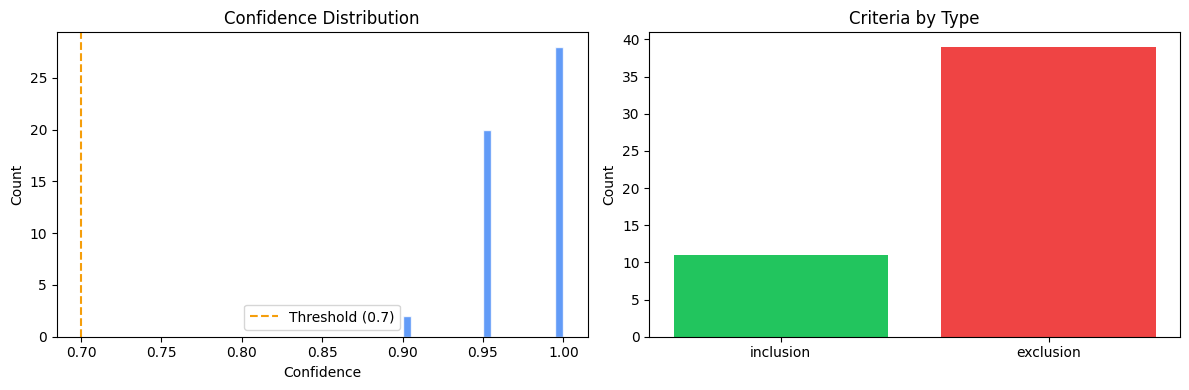

In [4]:
import matplotlib.pyplot as plt

if extraction and extraction.criteria:
    criteria = extraction.criteria

    # Type badge colors
    TYPE_COLORS = {"inclusion": "#22c55e", "exclusion": "#ef4444"}

    # Display each criterion with rich formatting
    for i, c in enumerate(criteria[:10]):  # Show first 10
        color = TYPE_COLORS.get(c.criteria_type, "#6b7280")

        print(f"\n{'=' * 70}")
        print(
            f"[{c.criteria_type.upper()}] [{c.category or 'uncategorized'}] (confidence: {c.confidence:.2f})"
        )
        print(f"  {c.text[:200]}")

        if c.temporal_constraint:
            tc = c.temporal_constraint
            print(f"  Temporal: {tc.duration} {tc.relation} {tc.reference_point or ''}")

        if c.numeric_thresholds:
            for nt in c.numeric_thresholds:
                upper = f"–{nt.upper_value}" if nt.upper_value else ""
                print(f"  Threshold: {nt.comparator} {nt.value}{upper} {nt.unit or ''}")

    # Confidence histogram
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    confidences = [c.confidence for c in criteria]
    axes[0].hist(confidences, bins=20, color="#3b82f6", edgecolor="white", alpha=0.8)
    axes[0].set_xlabel("Confidence")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Confidence Distribution")
    axes[0].axvline(x=0.7, color="#f59e0b", linestyle="--", label="Threshold (0.7)")
    axes[0].legend()

    # Type breakdown
    type_counts = {}
    for c in criteria:
        type_counts[c.criteria_type] = type_counts.get(c.criteria_type, 0) + 1
    colors = [TYPE_COLORS.get(t, "#6b7280") for t in type_counts.keys()]
    axes[1].bar(type_counts.keys(), type_counts.values(), color=colors)
    axes[1].set_title("Criteria by Type")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()
else:
    print("No criteria to display.")

## 5. Entity Grounding

For selected criteria, use `TerminologyRouter.route_entity()` for candidates,
then `medgemma_decide()` for selection. Displays `EntityGroundingResult` with candidate comparison.

In [6]:
import asyncio
from protocol_processor.tools.entity_decomposer import decompose_entities_from_criterion
from protocol_processor.tools.terminology_router import TerminologyRouter

# Same category -> entity_type fallback as parse node (routing.yaml keys)
_CATEGORY_TO_ENTITY_TYPE = {
    "medications": "Medication",
    "lab_values": "Lab_Value",
    "procedures": "Procedure",
    "demographics": "Demographic",
}


def _entity_type_for_criterion(category: str | None) -> str:
    return _CATEGORY_TO_ENTITY_TYPE.get(category or "", "Condition")


async def _ground_one_entity(
    entity: dict,
    criterion_text: str,
    router: TerminologyRouter,
) -> dict | None:
    """Route one entity and run MedGemma decision; return result row or None if skipped/failed."""
    entity_text = entity.get("text", "").strip()
    entity_type = entity.get("entity_type", "Condition")
    if not entity_text:
        return None
    if entity_type == "Consent":
        return {
            "criterion": criterion_text[:80],
            "entity": entity_text,
            "type": entity_type,
            "code": "—",
            "system": "—",
            "term": "(skipped)",
            "confidence": 0.0,
        }
    try:
        candidates = await router.route_entity(
            entity_text=entity_text, entity_type=entity_type
        )
    except Exception as e:
        return {
            "criterion": criterion_text[:80],
            "entity": entity_text,
            "type": entity_type,
            "code": "—",
            "system": "—",
            "term": f"(error: {e})",
            "confidence": 0.0,
        }
    if not candidates:
        return {
            "criterion": criterion_text[:80],
            "entity": entity_text,
            "type": entity_type,
            "code": "—",
            "system": "—",
            "term": "(no candidates)",
            "confidence": 0.0,
        }
    try:
        from protocol_processor.tools.medgemma_decider import medgemma_decide

        result = await medgemma_decide(
            entity={"text": entity_text, "entity_type": entity_type},
            candidates=candidates,
            criterion_context=criterion_text,
        )
        return {
            "criterion": criterion_text[:80],
            "entity": entity_text,
            "type": entity_type,
            "code": result.selected_code or "—",
            "system": result.selected_system or "—",
            "term": (result.preferred_term or "—")[:50],
            "confidence": result.confidence,
        }
    except Exception as e:
        return {
            "criterion": criterion_text[:80],
            "entity": entity_text,
            "type": entity_type,
            "code": "—",
            "system": "—",
            "term": f"(MedGemma: {e.__class__.__name__})",
            "confidence": 0.0,
        }


if extraction and extraction.criteria:
    router = TerminologyRouter()
    # Decompose first N criteria into entities (same as full app parse node)
    max_criteria = 5
    max_entities_total = 12
    entity_items: list[tuple[str, dict]] = []
    for c in extraction.criteria[:max_criteria]:
        decomposed = await decompose_entities_from_criterion(c.text, c.category)
        if decomposed:
            for ent in decomposed:
                entity_items.append((c.text, ent))
        else:
            entity_items.append(
                (
                    c.text,
                    {
                        "text": c.text,
                        "entity_type": _entity_type_for_criterion(c.category),
                    },
                )
            )
        if len(entity_items) >= max_entities_total:
            break
    entity_items = entity_items[:max_entities_total]

    print(
        f"Grounding {len(entity_items)} entities from {max_criteria} criteria (same flow as full app).\n"
    )

    async def _ground_all():
        out = []
        for criterion_text, entity in entity_items:
            row = await _ground_one_entity(entity, criterion_text, router)
            if row:
                out.append(row)
        return out

    results = asyncio.run(_ground_all())
    if results:
        df = pd.DataFrame(results)
        display(df)
    else:
        print("No entities grounded.")
else:
    print("No criteria available for grounding.")

Grounding 10 entities from 5 criteria (same flow as full app).

ℹ️  Including only specific tools: 6 tools specified
ℹ️  Included 6 tools by name filter
ℹ️  Number of tools after load tools: 6


/Users/noahdolevelixir/Code/medgemma-hackathon/.venv/lib/python3.13/site-packages/google/genai/_api_client.py:765: DeprecationWarning: Inheritance class AiohttpClientSession from ClientSession is discouraged
  class AiohttpClientSession(aiohttp.ClientSession):  # type: ignore[misc]
/Users/noahdolevelixir/Code/medgemma-hackathon/.venv/lib/python3.13/site-packages/google/genai/_api_client.py:765: DeprecationWarning: Inheritance class AiohttpClientSession from ClientSession is discouraged
  class AiohttpClientSession(aiohttp.ClientSession):  # type: ignore[misc]
/Users/noahdolevelixir/Code/medgemma-hackathon/.venv/lib/python3.13/site-packages/google/genai/_api_client.py:765: DeprecationWarning: Inheritance class AiohttpClientSession from ClientSession is discouraged
  class AiohttpClientSession(aiohttp.ClientSession):  # type: ignore[misc]
/Users/noahdolevelixir/Code/medgemma-hackathon/.venv/lib/python3.13/site-packages/google/genai/_api_client.py:765: DeprecationWarning: Inheritance clas

,criterion,entity,type,code,system,term,confidence
0,"Male or female, at least 18 years of age at sc...",male,Demographic,C1706180,umls,Male Gender,0.9
1,"Male or female, at least 18 years of age at sc...",female,Demographic,C1705498,umls,Female Phenotype,0.9
2,"Male or female, at least 18 years of age at sc...",age,Demographic,C0001779,umls,Age,1.0
3,"Scheduled to undergo primary, unilateral, tric...",primary unilateral tricompartmental total knee...,Procedure,—,—,(no candidates),0.0
4,"Scheduled to undergo primary, unilateral, tric...",spinal anesthesia,Procedure,C0002928,umls,Spinal Anesthesia,1.0
5,Primary indication for TKA is degenerative ost...,total knee arthroplasty,Procedure,C0086511,umls,Knee Replacement Arthroplasty,1.0
6,Primary indication for TKA is degenerative ost...,degenerative osteoarthritis of the knee,Condition,—,—,(no candidates),0.0
7,American Society of Anesthesiologists (ASA) ph...,American Society of Anesthesiologists physical...,Lab_Value,C0450990,umls,American Society of Anesthesiologists physical...,1.0
8,Female subjects must be surgically sterile,female,Demographic,C1705498,umls,Female Phenotype,1.0
9,Female subjects must be surgically sterile,surgical sterilization,Procedure,C3882131,snomed,Sterile fluted surgical drill,0.9


[Trace(trace_id=tr-47b137a88387c7f4b5c3ab45a3433af6), Trace(trace_id=tr-0ec4d9d520e4c157934b8157c81873fe), Trace(trace_id=tr-52055f461cdcbed45f581794f9bf6633), Trace(trace_id=tr-1dac9be79aa27465634a87ce00a8e8fa), Trace(trace_id=tr-17a3062d9a8e4220126b5edb9e6fb183), Trace(trace_id=tr-1c343f547d7377d01f3cebe753551a8b), Trace(trace_id=tr-d08274e71dcf1368914f2ec0e429ee7b), Trace(trace_id=tr-1a74a3da4b1177c02fec6bd72d08aed1), Trace(trace_id=tr-27e5f580b76ec7e31806a1187e2406ce), Trace(trace_id=tr-b96b4e97b249f967d0ea40c768a4537a)]

## 6. Expression Tree Visualization

Visualize `StructuredCriterionTree` as an indented text tree with unicode box-drawing characters.

In [7]:
from protocol_processor.schemas.structure import ExpressionNode, StructuredCriterionTree


def render_tree(
    node: dict | ExpressionNode, prefix: str = "", is_last: bool = True
) -> str:
    """Render an expression tree as indented text with box-drawing chars."""
    if isinstance(node, dict):
        node = ExpressionNode.model_validate(node)

    connector = "\u2514\u2500\u2500 " if is_last else "\u251c\u2500\u2500 "
    lines = []

    if node.type == "ATOMIC":
        entity = node.entity or "?"
        relation = node.relation or ""
        value = node.value or ""
        unit = node.unit or ""
        label = f"\u25cf {entity} {relation} {value} {unit}".strip()
    else:
        label = f"\u25b6 {node.type}"

    lines.append(f"{prefix}{connector}{label}")

    if node.children:
        child_prefix = prefix + ("    " if is_last else "\u2502   ")
        for i, child in enumerate(node.children):
            is_child_last = i == len(node.children) - 1
            lines.append(render_tree(child, child_prefix, is_child_last))

    return "\n".join(lines)


# Demo with a sample expression tree
sample_tree = StructuredCriterionTree(
    root=ExpressionNode(
        type="AND",
        children=[
            ExpressionNode(
                type="ATOMIC", entity="Age", relation=">=", value="18", unit="years"
            ),
            ExpressionNode(
                type="OR",
                children=[
                    ExpressionNode(
                        type="ATOMIC",
                        entity="HbA1c",
                        relation=">=",
                        value="7.0",
                        unit="%",
                    ),
                    ExpressionNode(
                        type="ATOMIC",
                        entity="Fasting glucose",
                        relation=">=",
                        value="126",
                        unit="mg/dL",
                    ),
                ],
            ),
            ExpressionNode(
                type="NOT",
                children=[
                    ExpressionNode(
                        type="ATOMIC",
                        entity="Pregnancy",
                        relation="contains",
                        value="current",
                    ),
                ],
            ),
        ],
    ),
    structure_confidence="llm",
    structure_model="gemini-2.5-flash",
)

print("Expression Tree (sample):")
print()
print(render_tree(sample_tree.root))
print(f"\nConfidence: {sample_tree.structure_confidence}")
print(f"Model: {sample_tree.structure_model}")

# If extraction produced structured_criterion, show those too
if extraction:
    for c in extraction.criteria[:3]:
        if hasattr(c, "conditions") and c.conditions:
            conds = c.conditions
            if isinstance(conds, list):
                print("\n--- Criterion conditions ---")
                print(f"Text: {c.text[:100]}")
                for cond in conds:
                    print(f"  - {cond}")

Expression Tree (sample):

└── ▶ AND
    ├── ● Age >= 18 years
    ├── ▶ OR
    │   ├── ● HbA1c >= 7.0 %
    │   └── ● Fasting glucose >= 126 mg/dL
    └── ▶ NOT
        └── ● Pregnancy contains current

Confidence: llm
Model: gemini-2.5-flash


## 7. Field Mappings

Display Entity | Relation | Value | Unit tables for the decomposed criteria.

In [8]:
# Sample field mappings (as would be generated by field_mapper.py)
sample_mappings = [
    {
        "entity": "HbA1c",
        "entity_code": "4548-4",
        "entity_system": "LOINC",
        "relation": ">=",
        "value": "7.0",
        "unit": "%",
        "omop_concept_id": "3004410",
    },
    {
        "entity": "Age",
        "entity_code": "30525-0",
        "entity_system": "LOINC",
        "relation": ">=",
        "value": "18",
        "unit": "years",
        "omop_concept_id": "4265453",
    },
    {
        "entity": "Type 2 Diabetes",
        "entity_code": "E11",
        "entity_system": "ICD-10",
        "relation": "contains",
        "value": "diagnosis",
        "unit": "",
        "omop_concept_id": "201826",
    },
    {
        "entity": "Metformin",
        "entity_code": "6809",
        "entity_system": "RxNorm",
        "relation": ">=",
        "value": "500",
        "unit": "mg/day",
        "omop_concept_id": "1503297",
    },
    {
        "entity": "eGFR",
        "entity_code": "62238-1",
        "entity_system": "LOINC",
        "relation": ">=",
        "value": "30",
        "unit": "mL/min/1.73m2",
        "omop_concept_id": "46236952",
    },
]

print("Field Mappings (Entity-Relation-Value-Unit):\n")

mapping_df = pd.DataFrame(
    [
        {
            "Entity": m["entity"],
            "System": m["entity_system"],
            "Code": m["entity_code"],
            "Relation": m["relation"],
            "Value": m["value"],
            "Unit": m["unit"] or "—",
            "OMOP ID": m.get("omop_concept_id", "—"),
        }
        for m in sample_mappings
    ]
)


# Style the DataFrame
def style_system(val):
    colors = {
        "LOINC": "background-color: #f3e8ff; color: #7c3aed",
        "ICD-10": "background-color: #fff7ed; color: #ea580c",
        "RxNorm": "background-color: #eff6ff; color: #2563eb",
        "SNOMED": "background-color: #f0fdf4; color: #16a34a",
    }
    return colors.get(val, "")


styled = mapping_df.style.map(style_system, subset=["System"])
display(styled)

# If we have actual extraction results with field mappings, show those
if extraction:
    actual_mappings = []
    for c in extraction.criteria:
        if c.conditions and isinstance(c.conditions, list):
            for cond in c.conditions:
                if isinstance(cond, str):
                    actual_mappings.append(
                        {"criterion": c.text[:60], "condition": cond}
                    )

    if actual_mappings:
        print(f"\n\nActual extracted conditions ({len(actual_mappings)} total):")
        display(pd.DataFrame(actual_mappings[:20]))

Field Mappings (Entity-Relation-Value-Unit):



,Entity,System,Code,Relation,Value,Unit,OMOP ID
0,HbA1c,LOINC,4548-4,>=,7.0,%,3004410
1,Age,LOINC,30525-0,>=,18,years,4265453
2,Type 2 Diabetes,ICD-10,E11,contains,diagnosis,—,201826
3,Metformin,RxNorm,6809,>=,500,mg/day,1503297
4,eGFR,LOINC,62238-1,>=,30,mL/min/1.73m2,46236952




Actual extracted conditions (16 total):


,criterion,condition
0,Female subjects must be surgically sterile,female subjects
1,Female subjects must be at least 2 years postm...,female subjects
2,Female subjects must have a monogamous partner...,female subjects
3,Female subjects must be practicing double-barr...,female subjects
4,Female subjects must be practicing abstinence ...,female subjects
5,Female subjects must be practicing abstinence ...,must agree to use double-barrier contraception...
6,"Female subjects must be using an insertable, i...",female subjects
7,Use of NSAIDs (except for low-dose aspirin use...,except for low-dose aspirin used for cardiopro...
8,If a subject is taking selective serotonin reu...,if a subject is taking one of these medication...
9,History of coronary or vascular stent placed w...,may be extended to 1 year if medically indicat...


---

## Summary

This notebook demonstrated the core ElixirTrials pipeline:

| Step | Tool | Output |
|------|------|--------|
| PDF Ingestion | `pymupdf` | Page count, metadata, text |
| Extraction | `extract_criteria_structured()` | `ExtractionResult` with typed criteria |
| Grounding | `TerminologyRouter` + `medgemma_decide()` | `EntityGroundingResult` with codes |
| Structure | Expression tree builder | `StructuredCriterionTree` (AND/OR/NOT) |
| Mapping | Field mapper | Entity-Relation-Value-Unit tables |

**Next steps:**
- Review criteria in the HITL UI (`/criteria` spreadsheet view)
- Export structured criteria for downstream CDM integration
- Run evaluation metrics against gold-standard annotations